In [128]:
print("Earthquake Project Started")

Earthquake Project Started


In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import regex
import streamlit
import sqlalchemy
import requests
from datetime import datetime
import os
print("All libraries are working!")

All libraries are working!


#DATA RETRIVAL

In [130]:
#adding url
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

In [131]:
#created empty list anb setting the start and end year
all_records = []
start_year = datetime.now().year -5
end_year = datetime.now().year

In [133]:
for year in range(start_year, end_year + 1):

    for month in range(1, 13):

        start_date = f'{year}-{month:02d}-01'

        if month == 12:
            end_date = f'{year+1}-01-01'
        else:
            end_date = f'{year}-{month+1:02d}-01'

        params = {
            'format': 'geojson',
            'starttime': start_date,
            'endtime': end_date,
            'minmagnitude': 3
        }

        response = requests.get(url, params=params)

        if response.status_code != 200:
            print(f'failed for {start_date}')
            continue

        try:
            data = response.json()
        except Exception as e:
            print(f'json error for {start_date}: {e}')
            continue

        for f in data['features']:

            p = f['properties']
            g = f['geometry']['coordinates']

            all_records.append({
                'id': f.get('id'),
                'time': pd.to_datetime(p.get('time'), unit='ms'),
                'updated': pd.to_datetime(p.get('updated'), unit='ms'),
                'latitude': g[1] if g else None,
                'longitude': g[0] if g else None,
                'depth_km': g[2] if g else None,
                'mag': p.get('mag'),
                'magType': p.get('magType'),
                'place': p.get('place'),
                'status': p.get('status'),
                'tsunami': p.get('tsunami'),
                'sig': p.get('sig'),
                'net': p.get('net'),
                'nst': p.get('nst'),
                'dmin': p.get('dmin'),
                'rms': p.get('rms'),
                'gap': p.get('gap'),
                'types': p.get('types'),
                'ids': p.get('ids'),
                'sources': p.get('sources'),
                'type': p.get('type'),
                'magSource': p.get('magSource'),
                'locationSource': p.get('locationSource'),
                'magNst': p.get('magNst'),
                'depthError': p.get('depthError'),
                'magError': p.get('magError')
            })   

In [134]:
#added the retrived records in empty list
df = pd.DataFrame(all_records)


In [135]:
df.columns

Index(['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag',
       'magType', 'place', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin',
       'rms', 'gap', 'types', 'ids', 'sources', 'type', 'magSource',
       'locationSource', 'magNst', 'depthError', 'magError'],
      dtype='object')

In [ ]:
#checking row, columns and start, end time to make sure data imported correctly
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Minimum date:", df["time"].min())
print("Maximum date:", df["time"].max())


Rows: 167691
Columns: 26
Minimum date: 2021-01-01 00:14:07.580000
Maximum date: 2026-09-30 08:15:17.486000


In [203]:
df.to_csv("earthquake_raw_fixed.csv", index=False)

In [137]:
#checking null values
df.isna().sum()

id                     0
time                   0
updated                0
latitude               0
longitude              0
depth_km               0
mag                    0
magType                0
place                  0
status                 0
tsunami                0
sig                    0
net                    0
nst                54107
dmin                6402
rms                   36
gap                 4622
types                  0
ids                    0
sources                0
type                   0
magSource         167691
locationSource    167691
magNst            167691
depthError        167691
magError          167691
dtype: int64

In [204]:
df.describe()

,time,updated,latitude,longitude,depth_km,mag,tsunami,sig,nst,dmin,rms,gap
count,167691,167691,167691.000000,167691.000000,167691.000000,167691.000000,167691.000000,167691.000000,113584.000000,161289.000000,167655.000000,163069.000000
mean,2023-05-18 10:32:57.700608512,2023-09-17 03:37:00.211954688,11.067312,4.913074,71.454190,4.259965,0.005671,287.982247,44.960276,3.270796,0.656102,121.806165
min,2021-01-01 00:14:07.580000,2021-01-01 10:15:32.601000,-84.493200,-179.999700,-3.740000,3.000000,0.000000,138.000000,0.000000,0.000000,0.000000,8.000000
25%,2021-12-14 16:52:09.964999936,2022-04-09 20:19:12.040000,-15.422050,-115.201300,10.000000,4.000000,0.000000,248.000000,20.000000,0.838000,0.490000,74.000000
50%,2022-12-27 13:57:50.199000064,2023-04-29 21:57:19.040000,13.879200,6.861500,20.000000,4.300000,0.000000,285.000000,32.000000,1.842000,0.650000,112.000000
75%,2024-11-01 11:02:54.930999808,2025-04-08 22:01:01.040000,38.078000,129.379700,69.996000,4.600000,0.000000,326.000000,56.000000,3.829000,0.820000,156.000000
max,2026-09-30 08:15:17.486000,2026-09-30 08:33:13.609000,87.375200,179.999400,683.578000,8.800000,1.000000,2910.000000,619.000000,62.558000,3.900000,359.000000
std,NaN,NaN,32.200996,128.594334,123.413217,0.610912,0.075093,91.998192,39.081810,4.522692,0.260260,63.184607


In [205]:
#checking dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167691 entries, 0 to 167690
Data columns (total 26 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              167691 non-null  object        
 1   time            167691 non-null  datetime64[ns]
 2   updated         167691 non-null  datetime64[ns]
 3   latitude        167691 non-null  float64       
 4   longitude       167691 non-null  float64       
 5   depth_km        167691 non-null  float64       
 6   mag             167691 non-null  float64       
 7   magType         167691 non-null  object        
 8   place           167691 non-null  object        
 9   status          167691 non-null  object        
 10  tsunami         167691 non-null  int64         
 11  sig             167691 non-null  int64         
 12  net             167691 non-null  object        
 13  nst             113584 non-null  float64       
 14  dmin            161289 non-null  flo

In [140]:
#checking duplicates
df.duplicated().sum()

np.int64(47407)

CLEANING DATA

In [206]:
#creating new datafarme to clean the data 
df_new = df.copy()

In [142]:
print('cleaned: ',df_new.shape)
print('raw: ', df.shape)

cleaned:  (167691, 26)
raw:  (167691, 26)


In [207]:
month= df_new['time'].dt.month.value_counts().sort_index()
month

time
1     15989
2     15347
3     16916
4     13571
5     12873
6     12740
7     15337
8     16191
9     13164
10    11299
11    11141
12    13123
Name: count, dtype: int64

In [144]:
year= df_new['time'].dt.year.value_counts().sort_index()
year

time
2021    43852
2022    40416
2023    26103
2024    18659
2025    22824
2026    15837
Name: count, dtype: int64

In [208]:
#checking null values 
df_new.isna().sum()

id                     0
time                   0
updated                0
latitude               0
longitude              0
depth_km               0
mag                    0
magType                0
place                  0
status                 0
tsunami                0
sig                    0
net                    0
nst                54107
dmin                6402
rms                   36
gap                 4622
types                  0
ids                    0
sources                0
type                   0
magSource         167691
locationSource    167691
magNst            167691
depthError        167691
magError          167691
dtype: int64

In [209]:
#DROPPING THE EMPTY COLUMNS BECAUSE THEY WHERE 100% MISSING IN OUR COLLECTED API DATA
empty_columns = [
    'magSource',
    'locationSource',
    'magNst',
    'depthError',
    'magError'
]
df_new =  df_new.drop(columns= empty_columns)

In [211]:
df_new.columns

Index(['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag',
       'magType', 'place', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin',
       'rms', 'gap', 'types', 'ids', 'sources', 'type'],
      dtype='object')

In [212]:
#ckecking the remaining columns count 
print('orignal_columns:',df.shape[1])
print('new_columns:',df_new.shape[1])

orignal_columns: 26
new_columns: 21


In [213]:
#CHECKING MISSING VALUES 
df_new.isnull().sum()

id               0
time             0
updated          0
latitude         0
longitude        0
depth_km         0
mag              0
magType          0
place            0
status           0
tsunami          0
sig              0
net              0
nst          54107
dmin          6402
rms             36
gap           4622
types            0
ids              0
sources          0
type             0
dtype: int64

#HANDLING THE MISSING COLUMNS WHICH HAS MISSING VALUES

In [214]:
#NST
df_new['nst'].dtype
df_new['nst'].describe()
df_new['nst'].isnull().sum()
print('DATA TYPES:' , df_new["nst"].dtype)
print('DESCRIBE :l' , df_new["nst"].describe())
print('MISSING VALUES:' , df_new["nst"].isnull().sum())

DATA TYPES: float64
DESCRIBE :l count    113584.000000
mean         44.960276
std          39.081810
min           0.000000
25%          20.000000
50%          32.000000
75%          56.000000
max         619.000000
Name: nst, dtype: float64
MISSING VALUES: 54107


In [215]:
#checking outliers
Q1 = df_new["nst"].quantile(0.25)
Q3 = df_new["nst"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 20.0
Q3: 56.0
IQR: 36.0
Lower limit: -34.0
Upper limit: 110.0


In [216]:
#found outliers 
df_new[df_new["nst"] < lower].shape[0]
df_new[df_new["nst"] > upper].shape[0]
print('LOWER:' , df_new[df_new["nst"] < lower].shape[0])
print('UPPER:', df_new[df_new["nst"] > upper].shape[0])


LOWER: 0
UPPER: 7611


In [218]:
#filling values using median because column has outliers or a skewed distribution.
print('MEDIAN:' , df_new['nst'].median())
df_new["nst"] = df_new["nst"].fillna(df_new["nst"].median())

MEDIAN: 32.0


In [219]:
df_new['nst'].isna().sum()

np.int64(0)

In [221]:
#dmin
df_new['dmin'].dtype
df_new['dmin'].describe()
df_new['dmin'].isnull().sum()
print('DATA TYPES:' , df_new["dmin"].dtype)
print('DESCRIBE :l' , df_new["dmin"].describe())
print('MISSING VALUES:' , df_new["dmin"].isnull().sum())

DATA TYPES: float64
DESCRIBE :l count    161289.000000
mean          3.270796
std           4.522692
min           0.000000
25%           0.838000
50%           1.842000
75%           3.829000
max          62.558000
Name: dmin, dtype: float64
MISSING VALUES: 6402


In [222]:
#checking outliers
Q1 = df_new["dmin"].quantile(0.25)
Q3 = df_new["dmin"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 0.838
Q3: 3.829
IQR: 2.991
Lower limit: -3.6485000000000003
Upper limit: 8.3155


In [223]:
#found outliers 
df_new[df_new["dmin"] < lower].shape[0]
df_new[df_new["dmin"] > upper].shape[0]
print('LOWER:' , df_new[df_new["dmin"] < lower].shape[0])
print('UPPER:', df_new[df_new["dmin"] > upper].shape[0])

LOWER: 0
UPPER: 12174


In [224]:
#filled values by using median because column has outliers or a skewed distribution.
print('MEDIAN:' , df_new['dmin'].median())
df_new["dmin"] = df_new["dmin"].fillna(df_new["dmin"].median())

MEDIAN: 1.842


In [225]:
df_new['dmin'].isna().sum()

np.int64(0)

In [226]:
#rms
df_new['rms'].dtype
df_new['rms'].describe()
df_new['rms'].isnull().sum()
print('DATA TYPES:' , df_new["rms"].dtype)
print('DESCRIBE :l' , df_new["rms"].describe())
print('MISSING VALUES:' , df_new["rms"].isnull().sum())

DATA TYPES: float64
DESCRIBE :l count    167655.000000
mean          0.656102
std           0.260260
min           0.000000
25%           0.490000
50%           0.650000
75%           0.820000
max           3.900000
Name: rms, dtype: float64
MISSING VALUES: 36


In [227]:
#checking outliers by using IQR
Q1 = df_new["rms"].quantile(0.25)
Q3 = df_new["rms"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 0.49
Q3: 0.82
IQR: 0.32999999999999996
Lower limit: -0.004999999999999949
Upper limit: 1.315


In [228]:
#found outliers 
df_new[df_new["rms"] < lower].shape[0]
df_new[df_new["rms"] > upper].shape[0]
print('LOWER:' , df_new[df_new["rms"] < lower].shape[0])
print('UPPER:', df_new[df_new["rms"] > upper].shape[0])

LOWER: 0
UPPER: 1107


In [229]:
#filled values by using median because column has outliers or a skewed distribution.
print('MEDIAN:' , df_new['rms'].median())
df_new["rms"] = df_new["rms"].fillna(df_new["rms"].median())

MEDIAN: 0.65


In [230]:
df_new['rms'].isna().sum()

np.int64(0)

In [231]:
#gap
df_new['gap'].dtype
df_new['gap'].describe()
df_new['gap'].isnull().sum()
print('DATA TYPES:' , df_new["gap"].dtype)
print('DESCRIBE :l' , df_new["gap"].describe())
print('MISSING VALUES:' , df_new["gap"].isnull().sum())

DATA TYPES: float64
DESCRIBE :l count    163069.000000
mean        121.806165
std          63.184607
min           8.000000
25%          74.000000
50%         112.000000
75%         156.000000
max         359.000000
Name: gap, dtype: float64
MISSING VALUES: 4622


In [168]:
#checking outliers by using IQR
Q1 = df_new["gap"].quantile(0.25)
Q3 = df_new["gap"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 74.0
Q3: 156.0
IQR: 82.0
Lower limit: -49.0
Upper limit: 279.0


In [232]:
#found outliers 
df_new[df_new["gap"] < lower].shape[0]
df_new[df_new["gap"] > upper].shape[0]
print('LOWER:' , df_new[df_new["gap"] < lower].shape[0])
print('UPPER:', df_new[df_new["gap"] > upper].shape[0])

LOWER: 0
UPPER: 163069


In [234]:
#filled values by using median because column has outliers or a skewed distribution.
print('MEDIAN:' , df_new['gap'].median())
df_new["gap"] = df_new["gap"].fillna(df_new["gap"].median())

MEDIAN: 112.0


In [235]:
df_new['gap'].isna().sum()

np.int64(0)

In [236]:
df_new.isnull().sum()

id           0
time         0
updated      0
latitude     0
longitude    0
depth_km     0
mag          0
magType      0
place        0
status       0
tsunami      0
sig          0
net          0
nst          0
dmin         0
rms          0
gap          0
types        0
ids          0
sources      0
type         0
dtype: int64

#VALIDATING EACH COLUMN 

In [237]:
#Latitude
print('Empty:', df_new['latitude'].isna().sum())
print("Min:", df_new["latitude"].min())
print("Max:", df_new["latitude"].max())

print("Invalid latitude:",
      ((df_new["latitude"] < -90) | (df_new["latitude"] > 90)).sum())

Empty: 0
Min: -84.4932
Max: 87.3752
Invalid latitude: 0


In [239]:
#Longitude 
print('Empty:', df_new['longitude'].isna().sum())
print("Min:" , df_new["longitude"].min())
print("Max:", df_new["longitude"].max())
print("Invalid Longitude:", ((df_new["longitude"] < -180) | (df_new["longitude"] > 180)).sum())

Empty: 0
Min: -179.9997
Max: 179.9994
Invalid Longitude: 0


In [240]:
#depth_km
print('Empty:', df_new['depth_km'].isna().sum())
print("Min:" , df_new["depth_km"].min())
print("Max:", df_new["depth_km"].max())
print("Negative depth:", (df_new["depth_km"] < 0).sum())

Empty: 0
Min: -3.74
Max: 683.578
Negative depth: 170


In [241]:
#mag
print('Empty:', df_new['mag'].isna().sum())
print('Empty:', df_new['mag'].isna().sum())
print("Min:" , df_new["mag"].min())
print("Max:", df_new["mag"].max())

Empty: 0
Empty: 0
Min: 3.0
Max: 8.8


In [242]:
#nst
print('Empty:', df_new['nst'].isna().sum())
print(df_new["nst"].describe())
print("Negative NST:",(df_new["nst"] < 0).sum())
print("Zero NST:",(df_new["nst"] == 0).sum())

Empty: 0
count    167691.000000
mean         40.778527
std          32.730252
min           0.000000
25%          25.000000
50%          32.000000
75%          41.000000
max         619.000000
Name: nst, dtype: float64
Negative NST: 0
Zero NST: 8


In [243]:
#dmin
print('Empty:', df_new['dmin'].isna().sum())
print(df_new["dmin"].describe())
print("Negative dmin:", (df_new["dmin"] < 0).sum())

Empty: 0
count    167691.000000
mean          3.216248
std           4.443962
min           0.000000
25%           0.872000
50%           1.842000
75%           3.706000
max          62.558000
Name: dmin, dtype: float64
Negative dmin: 0


In [244]:
#gap
print('Empty:', df_new['gap'].isna().sum())
print(df_new["gap"].describe())
print("Negative gap:",(df_new["gap"] < 0).sum())

Empty: 0
count    167691.000000
mean        121.535881
std          62.328431
min           8.000000
25%          75.000000
50%         112.000000
75%         153.000000
max         359.000000
Name: gap, dtype: float64
Negative gap: 0


In [245]:
#sig
print('Empty:', df_new['sig'].isna().sum())
print(df_new["sig"].describe())
print("Negative sig:", (df_new["sig"] < 0).sum())

Empty: 0
count    167691.000000
mean        287.982247
std          91.998192
min         138.000000
25%         248.000000
50%         285.000000
75%         326.000000
max        2910.000000
Name: sig, dtype: float64
Negative sig: 0


In [246]:
#tsunami
print('Empty:', df_new['tsunami'].isna().sum())
print(df_new["tsunami"].value_counts())

Empty: 0
tsunami
0    166740
1       951
Name: count, dtype: int64


In [247]:
#status
print('Empty:', df_new['status'].isna().sum())
print(df_new["status"].value_counts())

Empty: 0
status
reviewed     167476
automatic       215
Name: count, dtype: int64


In [248]:
#type
print('Empty:', df_new['type'].isna().sum())
print(df_new["type"].value_counts(dropna=False))

Empty: 0
type
earthquake                166416
mining explosion            1214
ice quake                     20
volcanic eruption             13
experimental explosion         8
mine collapse                  5
landslide                      5
other event                    5
quarry blast                   3
Landslide                      1
explosion                      1
Name: count, dtype: int64


In [249]:
df_new["type"] = df_new["type"].str.lower() #standardized
print('Empty:', df_new['type'].isna().sum())
print(df_new["type"].value_counts(dropna=False))

Empty: 0
type
earthquake                166416
mining explosion            1214
ice quake                     20
volcanic eruption             13
experimental explosion         8
landslide                      6
other event                    5
mine collapse                  5
quarry blast                   3
explosion                      1
Name: count, dtype: int64


In [250]:
#magType
print('Empty:', df_new['magType'].isna().sum())
print(df_new["magType"].value_counts())

Empty: 0
magType
mb            119136
ml             23988
mww            10205
md              9241
mwr             3850
mw               947
mb_lg            193
mwb               48
ml(texnet)        43
mlr               17
mlv                9
mwc                4
ms_vx              4
ms_20              2
mlg                2
mwp                1
mh                 1
Name: count, dtype: int64


In [251]:
#Date columns
print('Empty:', df_new['time'].isna().sum())
print(df_new["time"].dtype)
print(df_new["updated"].dtype)

print("Time range:")
print(df_new["time"].min())
print(df_new["time"].max())

print("Updated before event:",  (df_new["updated"] < df_new["time"]).sum())

Empty: 0
datetime64[ns]
datetime64[ns]
Time range:
2021-01-01 00:14:07.580000
2026-09-30 08:15:17.486000
Updated before event: 0


In [252]:
#id
print('Empty:', df_new['id'].isna().sum())
print('ID is unique:' , df_new["id"].is_unique)



Empty: 0
ID is unique: False


In [253]:
#net
print('Empty:', df_new['net'].isna().sum())
print(df_new["net"].value_counts())


Empty: 0
net
us        146396
pr          9223
ak          5443
tx          1501
nc          1412
hv          1392
ci          1251
nn           597
uu           155
ok           140
uw            78
iscgem        32
nm            30
se            29
av             8
ew             3
mb             1
Name: count, dtype: int64


In [254]:
#place
print('Empty:', df_new['place'].isna().sum())
print(df_new["place"].head(20))




Empty: 0
0           29 km SW of Villa Basilio Nievas, Argentina
1                                           Fiji region
2                       103 km SW of Basco, Philippines
3                               114 km N of M?n?b, Iran
4     184 km ENE of Olonkinbyen, Svalbard and Jan Mayen
5                    76 km NNE of Luquillo, Puerto Rico
6                    78 km NNE of Luquillo, Puerto Rico
7                       82 km N of Culebra, Puerto Rico
8                  99 km SE of Pondaguitan, Philippines
9                  69 km SE of Pondaguitan, Philippines
10                   75 km NNE of Luquillo, Puerto Rico
11                   76 km NNE of Luquillo, Puerto Rico
12                          52 km NE of Yairipok, India
13                  198 km SE of Sarangani, Philippines
14                          82 km SSE of Lethem, Guyana
15                         23 km ESE of Wright, Wyoming
16                   76 km NNE of Luquillo, Puerto Rico
17                   72 km NNE of Luqui

In [255]:
import regex as re
df_new["country"] = df_new["place"].str.extract(r",\s*([^,]+)$")
print(df_new[["place", "country"]].head(20))

                                                place                 country
0         29 km SW of Villa Basilio Nievas, Argentina               Argentina
1                                         Fiji region                     NaN
2                     103 km SW of Basco, Philippines             Philippines
3                             114 km N of M?n?b, Iran                    Iran
4   184 km ENE of Olonkinbyen, Svalbard and Jan Mayen  Svalbard and Jan Mayen
5                  76 km NNE of Luquillo, Puerto Rico             Puerto Rico
6                  78 km NNE of Luquillo, Puerto Rico             Puerto Rico
7                     82 km N of Culebra, Puerto Rico             Puerto Rico
8                99 km SE of Pondaguitan, Philippines             Philippines
9                69 km SE of Pondaguitan, Philippines             Philippines
10                 75 km NNE of Luquillo, Puerto Rico             Puerto Rico
11                 76 km NNE of Luquillo, Puerto Rico           

In [264]:
print("Country missing:", df_new["country"].isna().sum())

Country missing: 32773


In [265]:
df_new["place"].str.contains(",", regex=False).value_counts()

place
True     134918
False     32773
Name: count, dtype: int64

In [266]:
#show us the most common place formats that failed the Regex.
df_new.loc[df_new["country"].isna(), "place"].value_counts().head()

place
South Sandwich Islands region       5405
Kermadec Islands region             3298
south of the Fiji Islands           2903
Fiji region                         1993
southeast of the Loyalty Islands    1713
Name: count, dtype: int64

In [267]:
#types
print('Empty:', df_new['types'].isna().sum())
print(df_new["types"].head())


Empty: 0
0    dyfi,moment-tensor,origin,phase-data
1                       origin,phase-data
2                       origin,phase-data
3                       origin,phase-data
4                       origin,phase-data
Name: types, dtype: object


In [268]:
df_new["types"] = df_new["types"].str.strip(",")
print(df_new["types"].head())

0    dyfi,moment-tensor,origin,phase-data
1                       origin,phase-data
2                       origin,phase-data
3                       origin,phase-data
4                       origin,phase-data
Name: types, dtype: object


In [269]:
#ids
print('Empty:', df_new['ids'].isna().sum())
df_new["ids"] = df_new['ids'].str.strip(",")
print(df_new["ids"].head())


Empty: 0
0    us6000ddi8
1    us6000dev6
2    us6000dev5
3    us6000ddhs
4    us6000dev4
Name: ids, dtype: object


In [270]:
#sources
print('Empty:', df_new['sources'].isna().sum())
df_new["sources"] = df_new['sources'].str.strip(",")
print(df_new["sources"].head())

Empty: 0
0    us
1    us
2    us
3    us
4    us
Name: sources, dtype: object


CHECKING THE ENTIRE DATA AFTER DATA CLEANING

In [271]:
print("Rows:", df_new.shape[0])
print("Columns:", df_new.shape[1])

print("\nDuplicate rows:")
print(df_new.duplicated().sum())

print("\nMissing values:")
print(df_new.isnull().sum())


print("\nData types:")
print(df_new.dtypes)

Rows: 167691
Columns: 22

Duplicate rows:
47407

Missing values:
id               0
time             0
updated          0
latitude         0
longitude        0
depth_km         0
mag              0
magType          0
place            0
status           0
tsunami          0
sig              0
net              0
nst              0
dmin             0
rms              0
gap              0
types            0
ids              0
sources          0
type             0
country      32773
dtype: int64

Data types:
id                   object
time         datetime64[ns]
updated      datetime64[ns]
latitude            float64
longitude           float64
depth_km            float64
mag                 float64
magType              object
place                object
status               object
tsunami               int64
sig                   int64
net                  object
nst                 float64
dmin                float64
rms                 float64
gap                 float64
types          

In [272]:
df_new.drop(columns=["country"], inplace=True)

In [276]:
print("Rows:", df_new.shape[0])
print("Columns:", df_new.shape[1])

print("\nDuplicate rows:")
print(df_new.duplicated().sum())

print("\nMissing values:")
print(df_new.isnull().sum())


print("\nData types:")
print(df_new.dtypes)

Rows: 167691
Columns: 21

Duplicate rows:
47407

Missing values:
id           0
time         0
updated      0
latitude     0
longitude    0
depth_km     0
mag          0
magType      0
place        0
status       0
tsunami      0
sig          0
net          0
nst          0
dmin         0
rms          0
gap          0
types        0
ids          0
sources      0
type         0
dtype: int64

Data types:
id                   object
time         datetime64[ns]
updated      datetime64[ns]
latitude            float64
longitude           float64
depth_km            float64
mag                 float64
magType              object
place                object
status               object
tsunami               int64
sig                   int64
net                  object
nst                 float64
dmin                float64
rms                 float64
gap                 float64
types                object
ids                  object
sources              object
type                 object
dtype:

In [280]:
df_new.describe()

,time,updated,latitude,longitude,depth_km,mag,tsunami,sig,nst,dmin,rms,gap
count,167691,167691,167691.000000,167691.000000,167691.000000,167691.000000,167691.000000,167691.000000,167691.000000,167691.000000,167691.000000,167691.000000
mean,2023-05-18 10:32:57.700608512,2023-09-17 03:37:00.211954688,11.067312,4.913074,71.454190,4.259965,0.005671,287.982247,40.778527,3.216248,0.656101,121.535881
min,2021-01-01 00:14:07.580000,2021-01-01 10:15:32.601000,-84.493200,-179.999700,-3.740000,3.000000,0.000000,138.000000,0.000000,0.000000,0.000000,8.000000
25%,2021-12-14 16:52:09.964999936,2022-04-09 20:19:12.040000,-15.422050,-115.201300,10.000000,4.000000,0.000000,248.000000,25.000000,0.872000,0.490000,75.000000
50%,2022-12-27 13:57:50.199000064,2023-04-29 21:57:19.040000,13.879200,6.861500,20.000000,4.300000,0.000000,285.000000,32.000000,1.842000,0.650000,112.000000
75%,2024-11-01 11:02:54.930999808,2025-04-08 22:01:01.040000,38.078000,129.379700,69.996000,4.600000,0.000000,326.000000,41.000000,3.706000,0.820000,153.000000
max,2026-09-30 08:15:17.486000,2026-09-30 08:33:13.609000,87.375200,179.999400,683.578000,8.800000,1.000000,2910.000000,619.000000,62.558000,3.900000,359.000000
std,NaN,NaN,32.200996,128.594334,123.413217,0.610912,0.075093,91.998192,32.730252,4.443962,0.260232,62.328431


In [281]:
print("Shape:", df_new.shape)
print("Number of columns:", len(df_new.columns))

Shape: (167691, 21)
Number of columns: 21


In [282]:
print(df_new.columns.tolist())

['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag', 'magType', 'place', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin', 'rms', 'gap', 'types', 'ids', 'sources', 'type']


SQL INSERTION 

In [283]:
#Saving the data in csv file before insertion
#index=False means Pandas doesn't add the DataFrame index as an extra column.
df_new.to_csv('earthquake_cleaned.csv', index= False) 

In [284]:
#make sure fikle was saved 
print(os.path.exists("earthquake_cleaned.csv"))

True


In [285]:
print("Rows:", df_new.shape[0])
print("Columns:", df_new.shape[1])
print(df_new.columns.tolist())

Rows: 167691
Columns: 21
['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag', 'magType', 'place', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin', 'rms', 'gap', 'types', 'ids', 'sources', 'type']


In [286]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="2910",
    database="earthquake_db"
)

print("Connected successfully!")

Connected successfully!


In [287]:
print(conn.is_connected())

True


In [288]:
print(df_new.shape)
print(df_new.columns)

(167691, 21)
Index(['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag',
       'magType', 'place', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin',
       'rms', 'gap', 'types', 'ids', 'sources', 'type'],
      dtype='object')


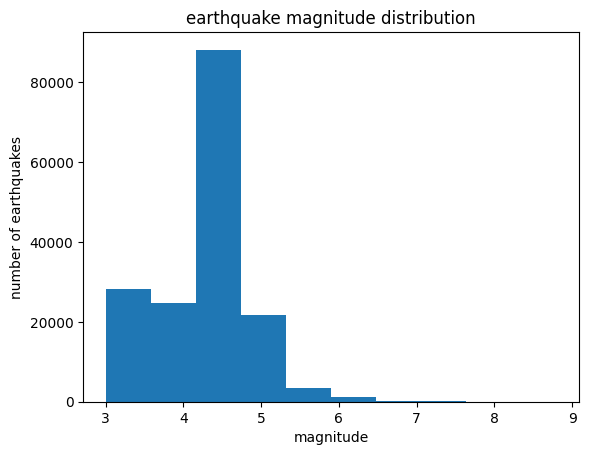

In [291]:
import matplotlib.pyplot as plt

#Magnitude distribution
plt.hist(df['mag'], bins=10)
plt.xlabel('magnitude')
plt.ylabel('number of earthquakes')
plt.title('earthquake magnitude distribution')
plt.show()

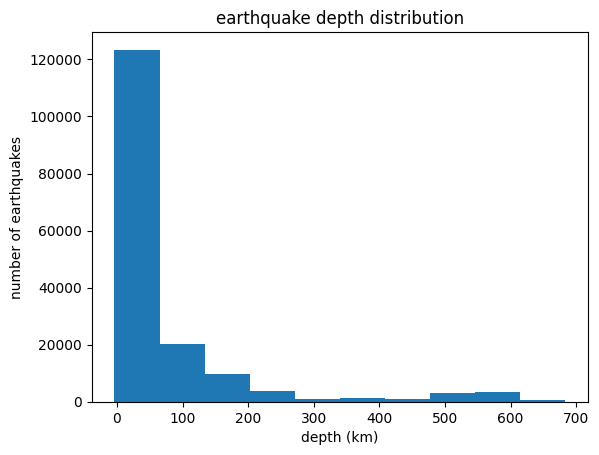

In [292]:
#Depth distribution
plt.hist(df['depth_km'], bins=10)
plt.xlabel('depth (km)')
plt.ylabel('number of earthquakes')
plt.title('earthquake depth distribution')
plt.show()

In [293]:
df['year'] = df['time'].dt.year
yearly_counts = df['year'].value_counts().sort_index()
yearly_counts

year
2021    43852
2022    40416
2023    26103
2024    18659
2025    22824
2026    15837
Name: count, dtype: int64

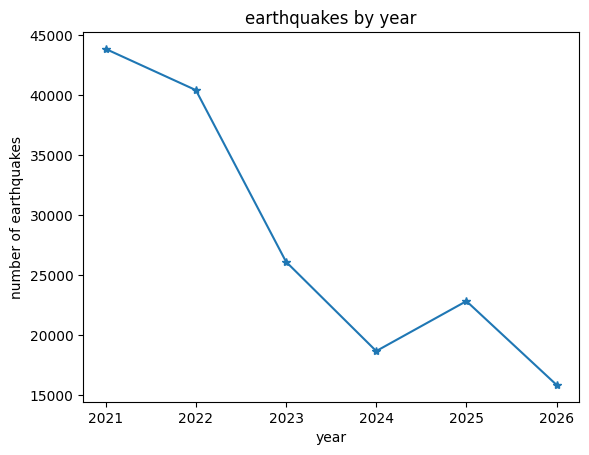

In [294]:
#Earthquakes by year
plt.plot(yearly_counts.index, yearly_counts.values, marker='*')
plt.xlabel('year')
plt.ylabel('number of earthquakes')
plt.title('earthquakes by year')
plt.show()

In [295]:
#Earthquakes by month
df["months"] = df['time'].dt.month_name()
month_order = ['January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December']
monthly_counts = df['months'].value_counts().reindex(month_order)
monthly_counts

months
January      15989
February     15347
March        16916
April        13571
May          12873
June         12740
July         15337
August       16191
September    13164
October      11299
November     11141
December     13123
Name: count, dtype: int64

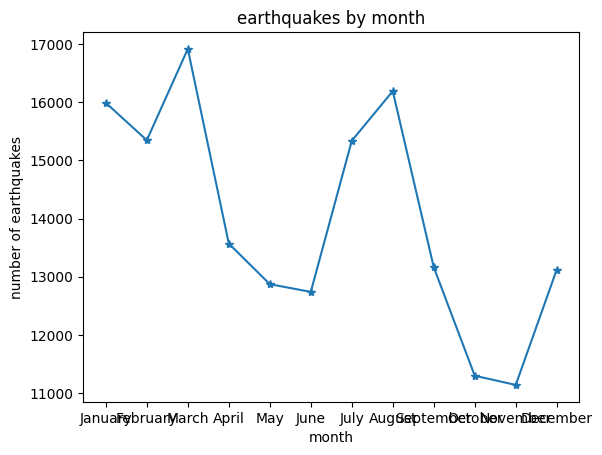

In [297]:
#Earthquakes by month 
plt.plot(monthly_counts.index, monthly_counts.values, marker= '*')
plt.xlabel ('month')
plt.ylabel('number of earthquakes')
plt.title('earthquakes by month')
plt.show()